#### Random Walker for cluster detection
Imagine the river network as undirected for this application, to allow a random walker to walk downstream as well as upstream.

In [2]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

id_conversion = pd.read_csv('site_id_naming_reference.csv', dtype={'site_id': str})

metadata = metadata.merge(id_conversion[['site_id', 'site_rename']], on='site_id', how='left')
metadata['site_rename'] = metadata['site_rename'].str.replace(' ', '', regex=False)

metadata[['site_id', 'site_name', 'site_rename']]

graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"),
              ("site7", "site8"),
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"),
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins
river_network = pp.Graph.from_edge_list(graph_edges_all).to_undirected()
A = river_network.sparse_adj_matrix();

In [3]:
# Functions reused from Notebook 06_04_InfoMap 

from collections import defaultdict
import seaborn as sns

def log2_0(x):
    return 0 if x == 0 else np.log2(x)

def minimal_code_length(p, module_map):
    module_to_nodes = defaultdict(list)
    for node in module_map:
        module_to_nodes[module_map[node]].append(node)
    module_labels = set(module_map.values())
    transitions = len(p) - 1
    within_prob = defaultdict(lambda: 0.0)
    exit_prob = defaultdict(lambda: 0.0)
    node_prob = defaultdict(lambda: 0.0)
    current_module = module_map[p[0]]
    node_prob[p[0]] += 1
    exit_prob[current_module] += 1
    for x in p[1:]:
        node_prob[x] += 1
        if module_map[x] == current_module:
            within_prob[current_module] += 1
        else:
            exit_prob[current_module] += 1
            current_module = module_map[x]
    for i in module_labels:
        exit_prob[i] = exit_prob[i] / (transitions + 1)
        within_prob[i] = within_prob[i] / transitions
    q = sum(exit_prob.values())
    for n in module_map:
        node_prob[n] = node_prob[n] / (transitions + 1)
    S = 0.0
    H_Q = 0.0
    for m in module_labels:
        D = sum(node_prob[w] for w in module_to_nodes[m])
        H_Q += -D * log2_0(D)
        H_Pi = sum(-(node_prob[w] / D) * log2_0(node_prob[w] / D) for w in module_to_nodes[m])
        S += D * H_Pi
    return q * H_Q + S

def merge(C, x, y):
    D = {}
    for i in C:
        if C[i] == x:
            D[i] = y
        else:
            D[i] = C[i]
    return D

def find_communities_walk(network, walk, iterations=100):
    C = {}
    c = 0
    for n in network.nodes:
        C[n] = c
        c += 1
    dl = minimal_code_length(walk, C)
    communities = set(C.values())
    dl_vals = [dl]
    for _ in range(iterations):
        if len(communities) > 1:
            ind = np.random.choice(len(walk) - 2)
            x, y = C[walk[ind]], C[walk[ind + 1]]
            dl_new = minimal_code_length(walk, merge(C, x, y))
            if dl_new < dl:
                C = merge(C, x, y)
                communities = set(C.values())
                dl = dl_new
            dl_vals.append(dl)
    return C, dl_vals

# New function to generate random walks on the graph, which we can then use to find communities using the above functions.
def random_walk(network, steps, seed=None):
    neighbours = defaultdict(list)
    for v, w in network.edges:
        neighbours[v].append(w)
        neighbours[w].append(v)
    rng = np.random.default_rng(seed)
    start = rng.choice(list(network.nodes))
    walk = [start]
    for _ in range(steps):
        current = walk[-1]
        walk.append(rng.choice(neighbours[current]))
    return walk

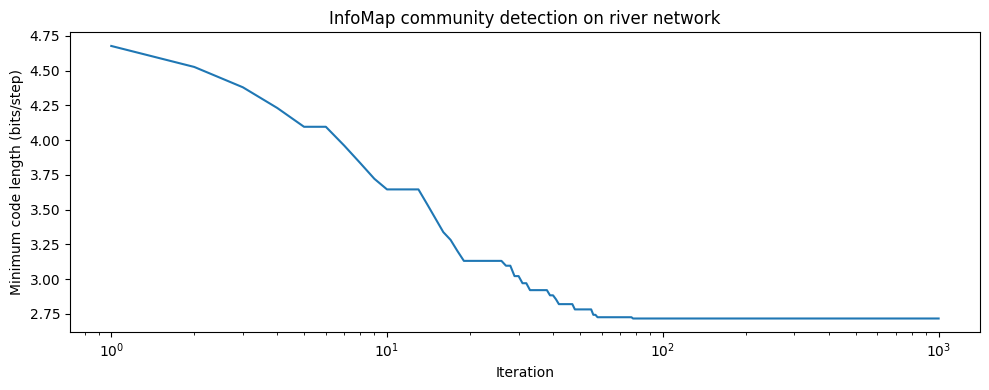

Detected 6 communities


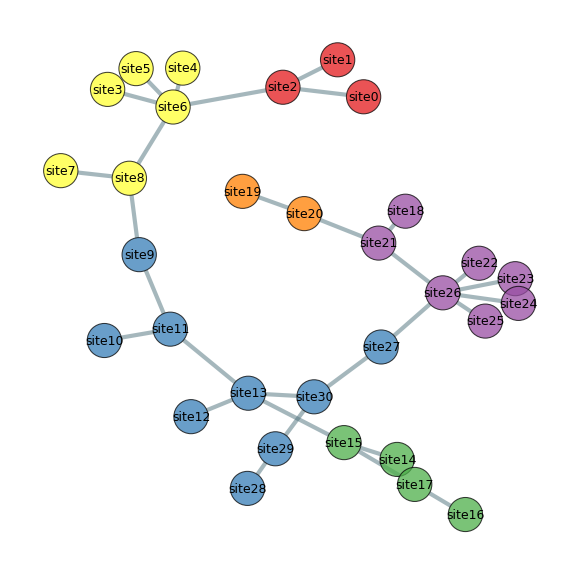

In [4]:
# ── Run random walk and detect communities ────────────────────────────────────

neighbours = defaultdict(list)
for v, w in river_network.edges:
    neighbours[v].append(w)
    neighbours[w].append(v)

def random_walk(network, steps, seed=None):
    rng = np.random.default_rng(seed)
    start = rng.choice(list(network.nodes))
    walk = [start]
    for _ in range(steps):
        current = walk[-1]
        walk.append(rng.choice(neighbours[current]))
    return walk

seed = 42
np.random.seed(seed)
walk = random_walk(river_network, steps=500000, seed=42)

C, dl_vals = find_communities_walk(river_network, walk, iterations=1000)

plt.figure(figsize=(10, 4))
plt.semilogx(range(1, len(dl_vals) + 1), dl_vals)
plt.xlabel("Iteration")
plt.ylabel("Minimum code length (bits/step)")
plt.title("InfoMap community detection on river network")
plt.tight_layout()
plt.savefig("figures/infomap_convergence_2.png", dpi=300);
plt.show()

community_ids = sorted(set(C.values()))
remap = {old: new for new, old in enumerate(community_ids)}
colors = sns.color_palette("Set1", len(community_ids)).as_hex()

node_colors = [colors[remap[C[v]]] for v in river_network.nodes]
print(f"Detected {len(community_ids)} communities")
pp.plot(river_network, node_color=node_colors,
        node_label=[v for v in river_network.mapping.node_ids], filename="figures/infomap_communities_2.png", dpi=300);

Apparently, the InfoMap algorithm detects somewhat meaningful communities, but more than anticipated - That is probably because the InfoMap algorithm prefers smaller communities, as larger communities that takes away the advantage of reduced code length.